Epoch 1, Loss: 163.8203
Epoch 2, Loss: 121.3121
Epoch 3, Loss: 114.6512
Epoch 4, Loss: 111.7190
Epoch 5, Loss: 109.9801
Epoch 6, Loss: 108.8468
Epoch 7, Loss: 108.0328
Epoch 8, Loss: 107.3845
Epoch 9, Loss: 106.8329
Epoch 10, Loss: 106.4066
模型参数已保存！


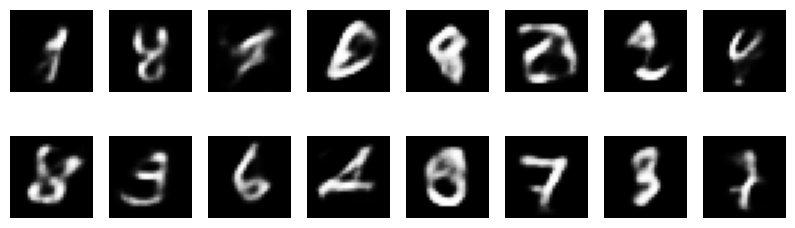

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torchvision import datasets, transforms

# 定义 VAE
class VAE(nn.Module):
    def __init__(self, input_dim=784, hidden_dim=400, latent_dim=20):
        super(VAE, self).__init__()
        # 编码器
        self.fc1 = nn.Linear(input_dim, hidden_dim)
        self.fc2_mu = nn.Linear(hidden_dim, latent_dim)  # 均值
        self.fc2_logvar = nn.Linear(hidden_dim, latent_dim)  # 方差

        # 解码器
        self.fc3 = nn.Linear(latent_dim, hidden_dim)
        self.fc4 = nn.Linear(hidden_dim, input_dim)

    def encode(self, x):
        h = F.relu(self.fc1(x))
        mu = self.fc2_mu(h)
        logvar = self.fc2_logvar(h)
        return mu, logvar

    def reparameterize(self, mu, logvar):
        std = torch.exp(0.5 * logvar)
        eps = torch.randn_like(std)
        return mu + eps * std

    def decode(self, z):
        h = F.relu(self.fc3(z))
        return torch.sigmoid(self.fc4(h))  # 输出为 0-1 之间

    def forward(self, x):
        mu, logvar = self.encode(x)
        z = self.reparameterize(mu, logvar)
        return self.decode(z), mu, logvar

# 计算 VAE 损失
def loss_function(recon_x, x, mu, logvar):
    BCE = F.binary_cross_entropy(recon_x, x, reduction='sum')  # 计算重构误差
    KLD = -0.5 * torch.sum(1 + logvar - mu.pow(2) - logvar.exp())  # 计算 KL 散度
    return BCE + KLD


# 加载数据
transform = transforms.ToTensor()
train_loader = torch.utils.data.DataLoader(
    datasets.MNIST('./data', train=True, download=True, transform=transform),
    batch_size=128, shuffle=True
)

# 初始化模型和优化器
vae = VAE()
optimizer = optim.Adam(vae.parameters(), lr=1e-3)

# 训练 VAE
epochs = 10
vae.train()
for epoch in range(epochs):
    total_loss = 0
    for x, _ in train_loader:
        x = x.view(-1, 784)  # 展平成向量
        optimizer.zero_grad()
        recon_x, mu, logvar = vae(x)
        loss = loss_function(recon_x, x, mu, logvar)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
    
    print(f"Epoch {epoch+1}, Loss: {total_loss / len(train_loader.dataset):.4f}")

torch.save(vae.state_dict(), "vae_model.pth")
print("模型参数已保存！")

import matplotlib.pyplot as plt

vae.eval()
with torch.no_grad():
    z = torch.randn(16, 20)  # 从标准高斯分布采样
    samples = vae.decode(z).view(-1, 28, 28).numpy()

# 可视化生成的样本
fig, axes = plt.subplots(2, 8, figsize=(10, 3))
for i, ax in enumerate(axes.flat):
    ax.imshow(samples[i], cmap='gray')
    ax.axis('off')
plt.show()
